# Project 2 - Classification

**In this file:** 
+ Business Understanding + Data Undertanding + Evaluation (of analyzed models) 

=== 

**On other files:**
+ Business Understanding + Data Undertanding + Evaluation (of analyzed models).  *File Name:* ML_02_Business..ipynb 
+ Model Decision Trees.  *File Name:* ML_02_Model_DecisionTrees.ipynb
+ Model K-Nearest Neighbor (KNN).  *File Name:* ML_Model_KNN.ipynb
+ Model Logistic Regression.  *File Name:* ML_02_Model_LogisticR.ipynb
+ Models: Support Vector Machine (SVM), Neural networks and Naïve Bayes.  *File Name:* ML_02_Model_SVN_NN_NB.ipynb

===

#### **Group V**
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 20250183
+ Beatriz Lobão, 20250566
+ Joao Bernardino, 20250922
+ Lara Pereira, 20250921

## Business Understanding


**What is this Business:**
 + This business is a B2C. The business sells goods to customers via store, catalog, and website (e-commerce). 
 + They use mediums such as websites, catalogs, newsletters, and coupons as a strategy to increase sales. 


**About the Dataset:**

 + The dataset allegedly has data from 2 years of customers purchases. 
 + The dataset has customers information regarding education, marital status, kids and teens in the family, income (this may be a problem in the future). 
 + Has complained for the last 2 years, needs to be evaluated to understand why. 
 + Analyze also the campaigns made to understand the marketing effectiveness. 


**Problems:**

 + The 1st problem identified can be the marketing inefficiency of marketing campaigns, the lack of targeting or user consent. 
 + The main goal is to boost campaign efficiency, increase response, and reduce expenses in the target modeling.  


**Business Objective:**
 + The MKT wants to predict which customers are more likely to respond to a new marketing campaign based on previous data. 
 + Increase campaign efficiency by targeting the right customers.
 + Reduce marketing costs by avoiding contacting non-responders.
 + Maximize ROI 


**Sucess Criteria:**
 + The model must outperform a random baseline (AUC > 0.5). 
 + Evaluation will be using: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, Gain and Lift charts, and ROI analysis. 
 + Test 5 algorithms: Logistic Regression, SVM, KNN, Naive Bayes, and Decision Tree. 


## Data Undertanding

In [1]:
# Loading packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset and visualizing summary statistics
ds = pd.read_excel('/Users/anamoura/Desktop/MachineLearning/Project_02/campaign.xlsx', engine='openpyxl')
ds.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,665,2012-08-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2237.0,NaN,NaN,NaN,303.838623,336.576209,0.0,24.0,173.0,504.0,1493.0


In [3]:
# Show top rows
ds.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635.0,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11.0,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426.0,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11.0,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173.0,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# Quick shape overview
print("Shape:", ds.shape)
ds.info()

Shape: (2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2237 non-null   float64
 10  MntFruits            2238 non-null   float64
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2187 non-null   float64
 15  NumDealsPurchases   

#### Missing Values

In [5]:
#Check for missing values
missing = pd.DataFrame({
    'Count': ds.isnull().sum(),
    'Percentage (%)': (ds.isnull().sum() / len(ds) * 100).round(2)
})
missing[missing['Count'] > 0]

,Count,Percentage (%)
Income,24,1.07
MntWines,3,0.13
MntFruits,2,0.09
MntGoldProds,53,2.37


Observations: `Income` and `MntGoldProds` are the variables with most missing values in the dataset. 

#### Strange Values

In [6]:
# Check for invalid values (MntFishProducts showing a minimum of -1)
print("Rows with negative fish spending:", ds[ds['MntFishProducts'] < 0].shape[0])

# Check for strange values (MntSweetProducts showing from 75% to max)
print("Rows with spending above 75% to max. at sweet products:", ds[ds['MntSweetProducts'] > 33.25].shape[0])

# Check for strange values (Income showing from 75% to max)
print("Rows income higher that 75%:", ds[ds['Income'] > 68522.0].shape[0])

# Check for complains 
print("Rows with complains:", ds[ds['Complain'] > 0].shape[0])

# Check for Z_CostContact 
print("Rows with Cost Contact below 3:", ds[ds['Z_CostContact'] < 3].shape[0])

# Check for Z_Revenue 
print("Rows with Z_Revenue below 11:", ds[ds['Z_Revenue'] < 11].shape[0])

Rows with negative fish spending: 2
Rows with spending above 75% to max. at sweet products: 560
Rows income higher that 75%: 554
Rows with complains: 21
Rows with Cost Contact below 3: 0
Rows with Z_Revenue below 11: 0


Observations: 
+ Invalid spending in Fish Products (erro or devolutions?).  
+ Big Outliers in Sweet Products (error, typo?).
+ Z_CostContact and Z_Revenue provide no information. 
+ Low Complains (21). 

##### Cardinality

In [7]:
# Check cardinality of categorical variables
print("Unique Education levels:", ds['Education'].unique())
print("Unique Marital Status levels:", ds['Marital_Status'].unique())

Unique Education levels: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Unique Marital Status levels: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


##### Variable Distribution

Class Distribution:
          Count  Percentage
Response                   
0          1906   85.089286
1           334   14.910714


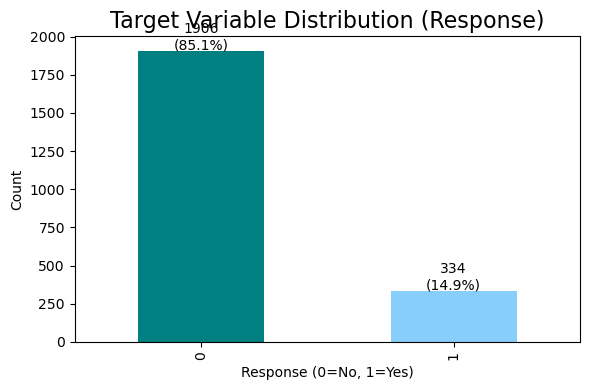

In [8]:
# Class distribution of target variable `Response`
response_counts = ds['Response'].value_counts()
response_pct = ds['Response'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(pd.DataFrame({'Count': response_counts, 'Percentage': response_pct}))

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
response_counts.plot(kind='bar', color=['teal', 'lightskyblue'], ax=ax)
ax.set_title('Target Variable Distribution (Response)', size = 16)
ax.set_xlabel('Response (0=No, 1=Yes)')
ax.set_ylabel('Count')
for i, v in enumerate(response_counts):
    ax.text(i, v + 10, f'{v}\n({response_pct.iloc[i]:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

Observations: 
- Imbalance exists in the response variable. Accuracy alone can be misleading; a model that classifies all negative has 99% accuracy. 
- Precision, recall, F1, and AUC are more appropriate metrics. 
- Some models (KNN, logistic regression) may need class_weight balanced. 

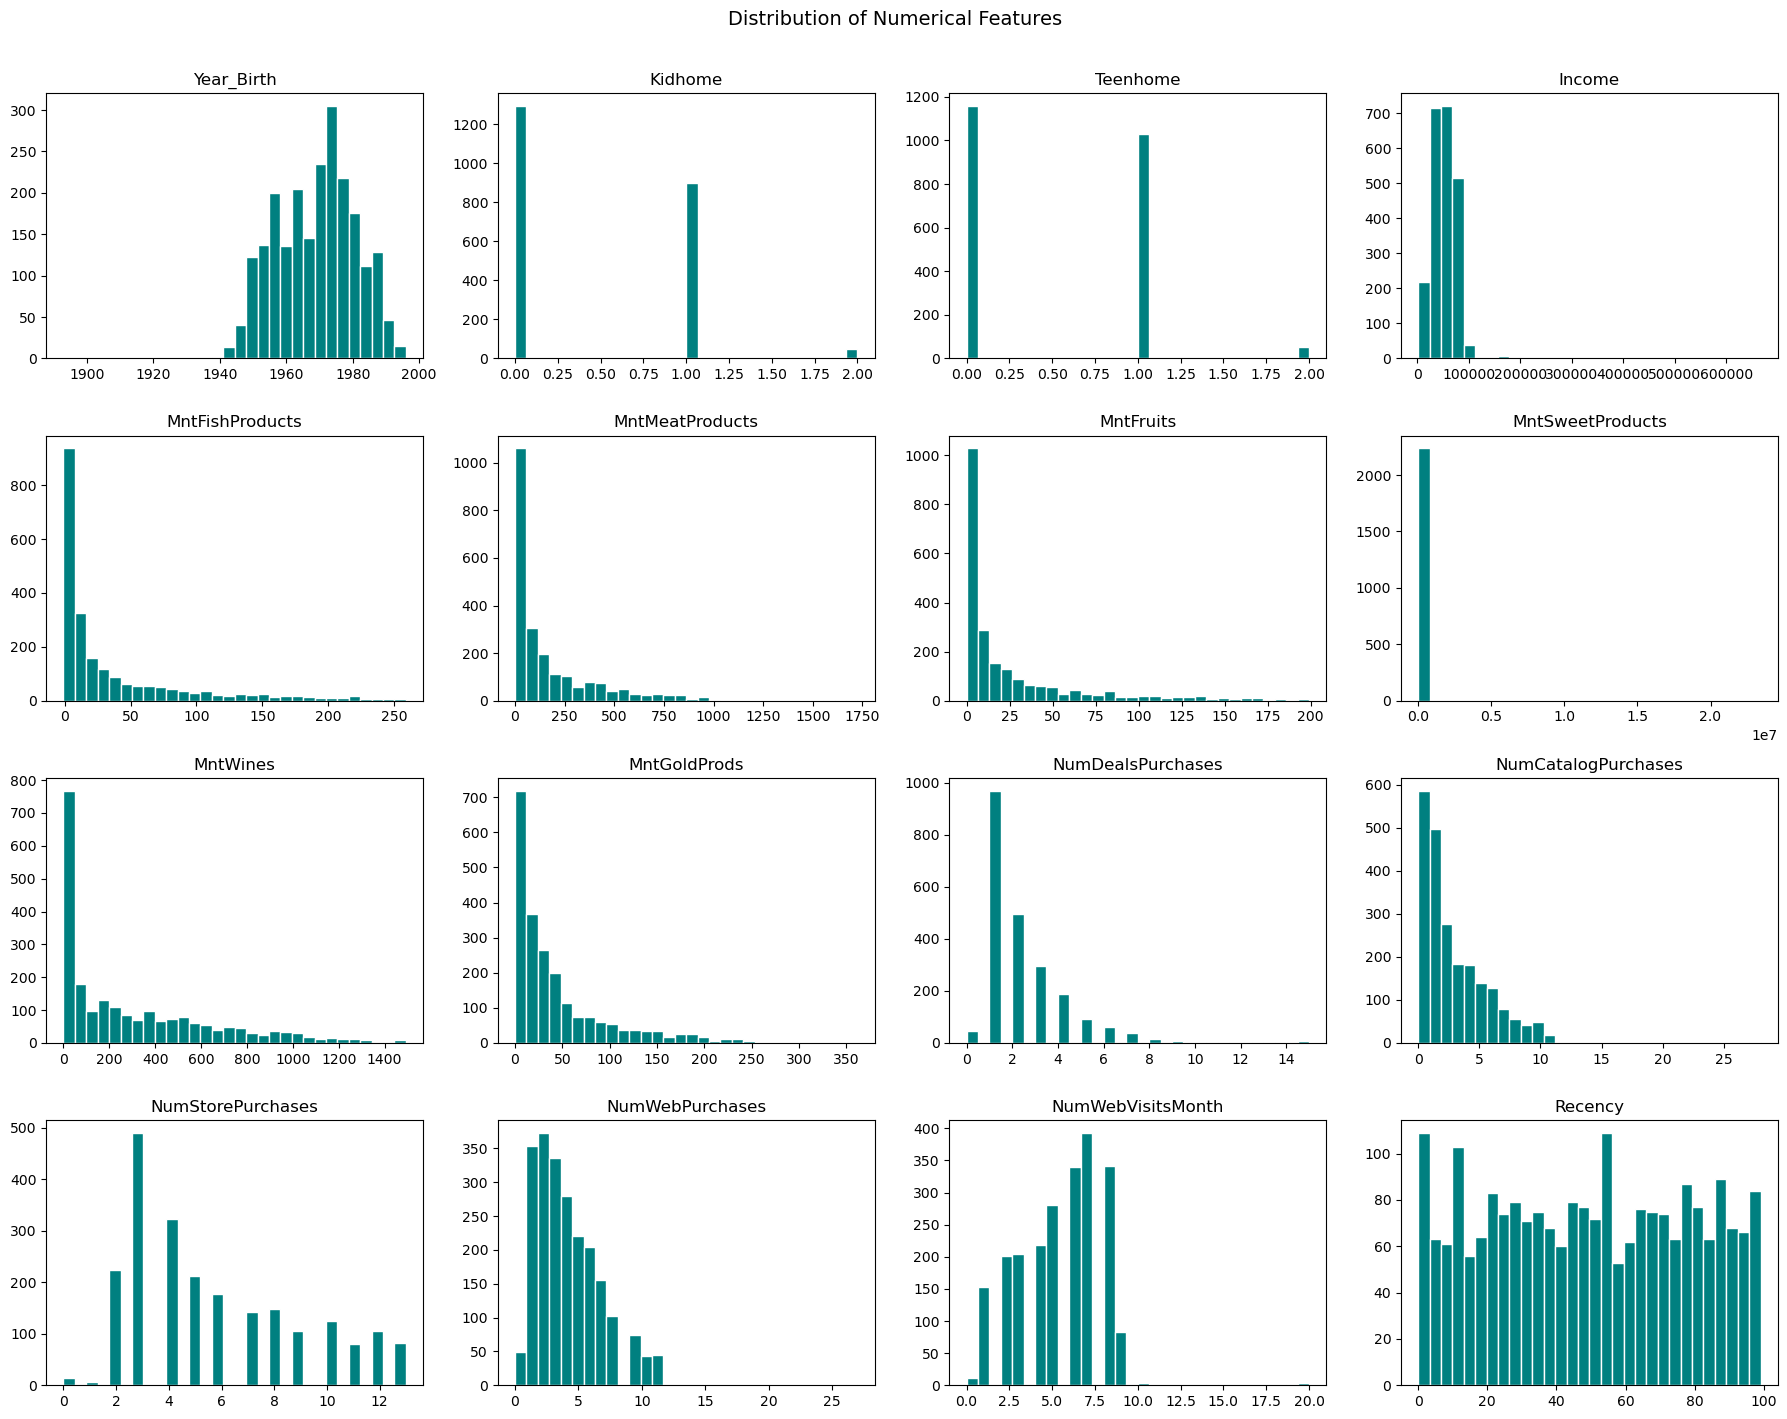

In [9]:
# Distribution plots for all numerical features
numerical_cols = ['Year_Birth','Kidhome','Teenhome', 'Income', 'MntFishProducts', 'MntMeatProducts', 'MntFruits',
                  'MntSweetProducts', 'MntWines', 'MntGoldProds',
                  'NumDealsPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                  'NumWebPurchases', 'NumWebVisitsMonth', 'Recency']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(ds[col].dropna(), bins=30, color='teal', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Observations: 
+ Skewness in variables Mnt___ 
+ Outliers in income, spending 
+ Bimodal distributions on Recency and year of birth 

##### Univariable Analysis

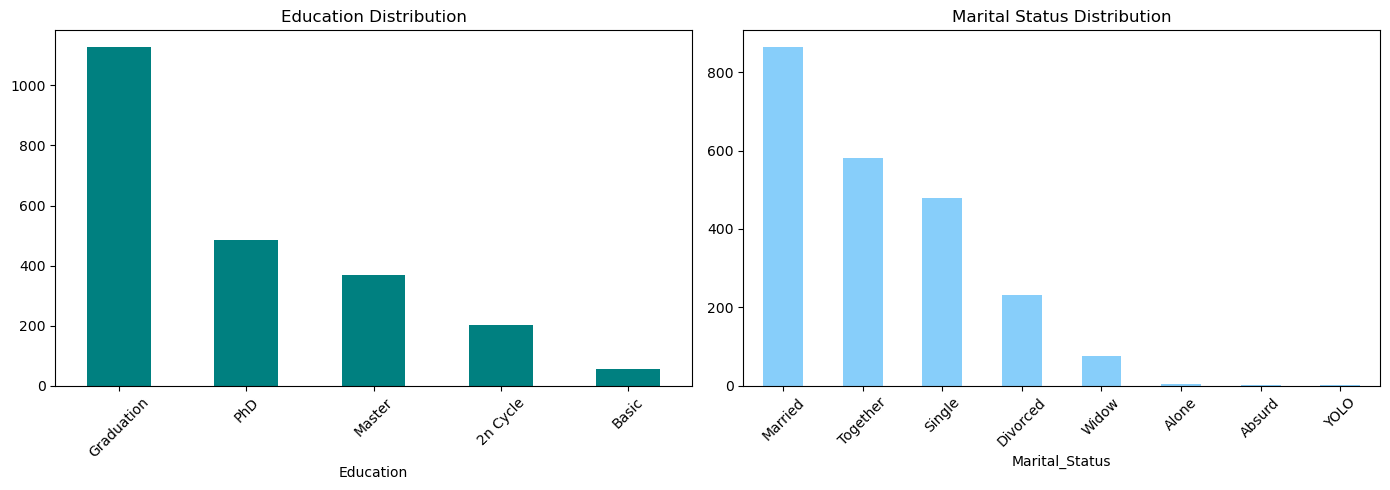

In [10]:
# Education and Marital status distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ds['Education'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Education Distribution')
axes[0].tick_params(axis='x', rotation=45)

ds['Marital_Status'].value_counts().plot(kind='bar', ax=axes[1], color='lightskyblue')
axes[1].set_title('Marital Status Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Observations: In Marital Status, there is 2 categories `Absurd` and `YOLO` that must be widraw or classified as `No Response`. See later what is the best case cenario. 

##### Bivariate Analysis

In [11]:
# Response rate by categorical variables
for col in ['Education', 'Marital_Status', 'Kidhome', 'Teenhome']:
    response_rate = ds.groupby(col)['Response'].mean().sort_values(ascending=False)
    print(f"\nResponse rate by {col}:")
    print(response_rate.round(3))


Response rate by Education:
Education
PhD           0.208
Master        0.154
Graduation    0.135
2n Cycle      0.108
Basic         0.037
Name: Response, dtype: float64

Response rate by Marital_Status:
Marital_Status
Absurd      0.500
YOLO        0.500
Alone       0.333
Widow       0.247
Single      0.221
Divorced    0.207
Married     0.113
Together    0.103
Name: Response, dtype: float64

Response rate by Kidhome:
Kidhome
0    0.172
1    0.122
2    0.042
Name: Response, dtype: float64

Response rate by Teenhome:
Teenhome
0    0.205
2    0.096
1    0.089
Name: Response, dtype: float64


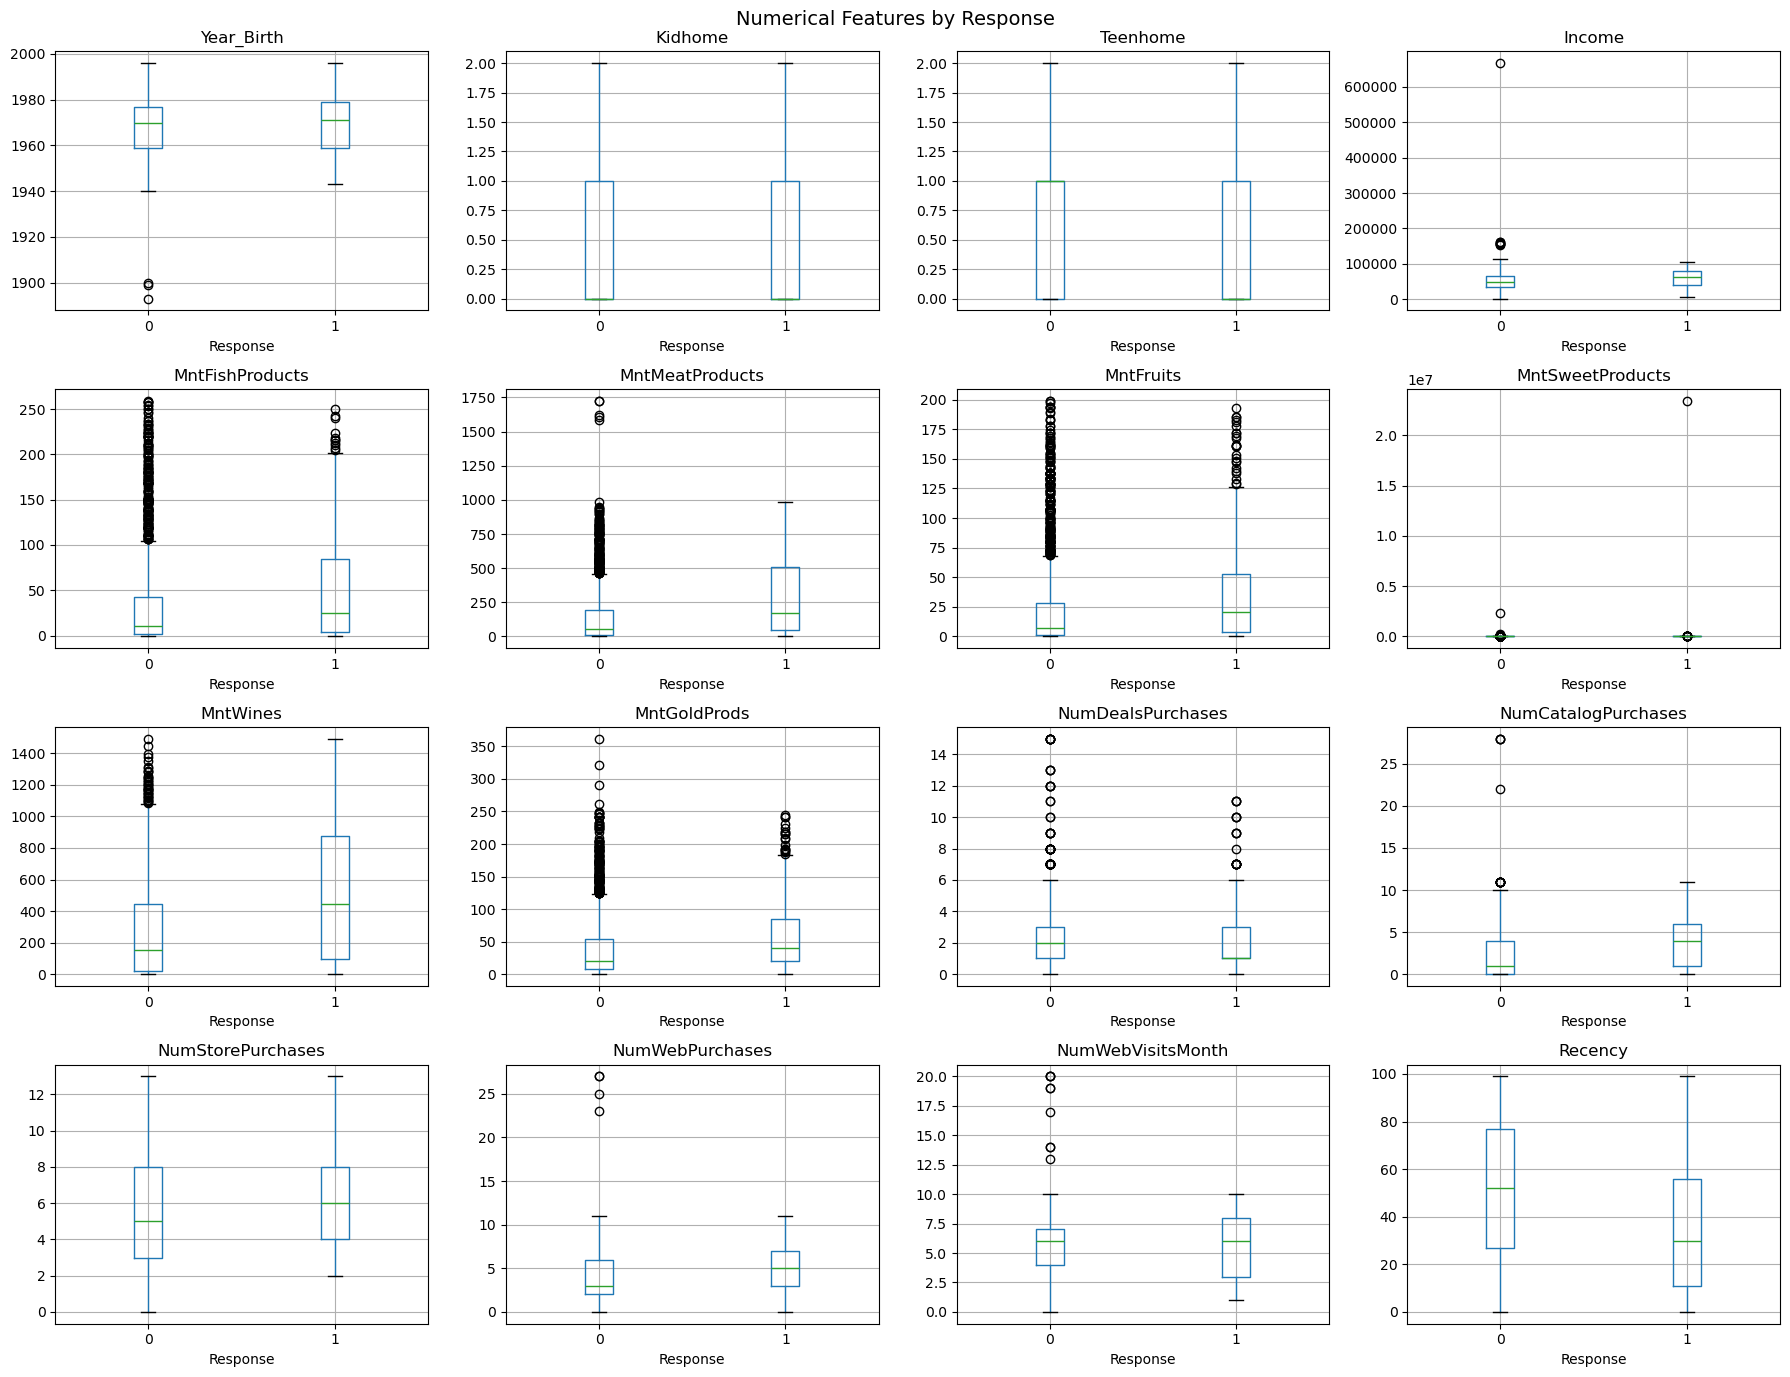

In [12]:
#Box plots of numerical variables and Responses
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ds.boxplot(column=col, by='Response', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Response')

plt.suptitle('Numerical Features by Response', fontsize=14)
plt.tight_layout()
plt.show()

##### Correlation Analysis

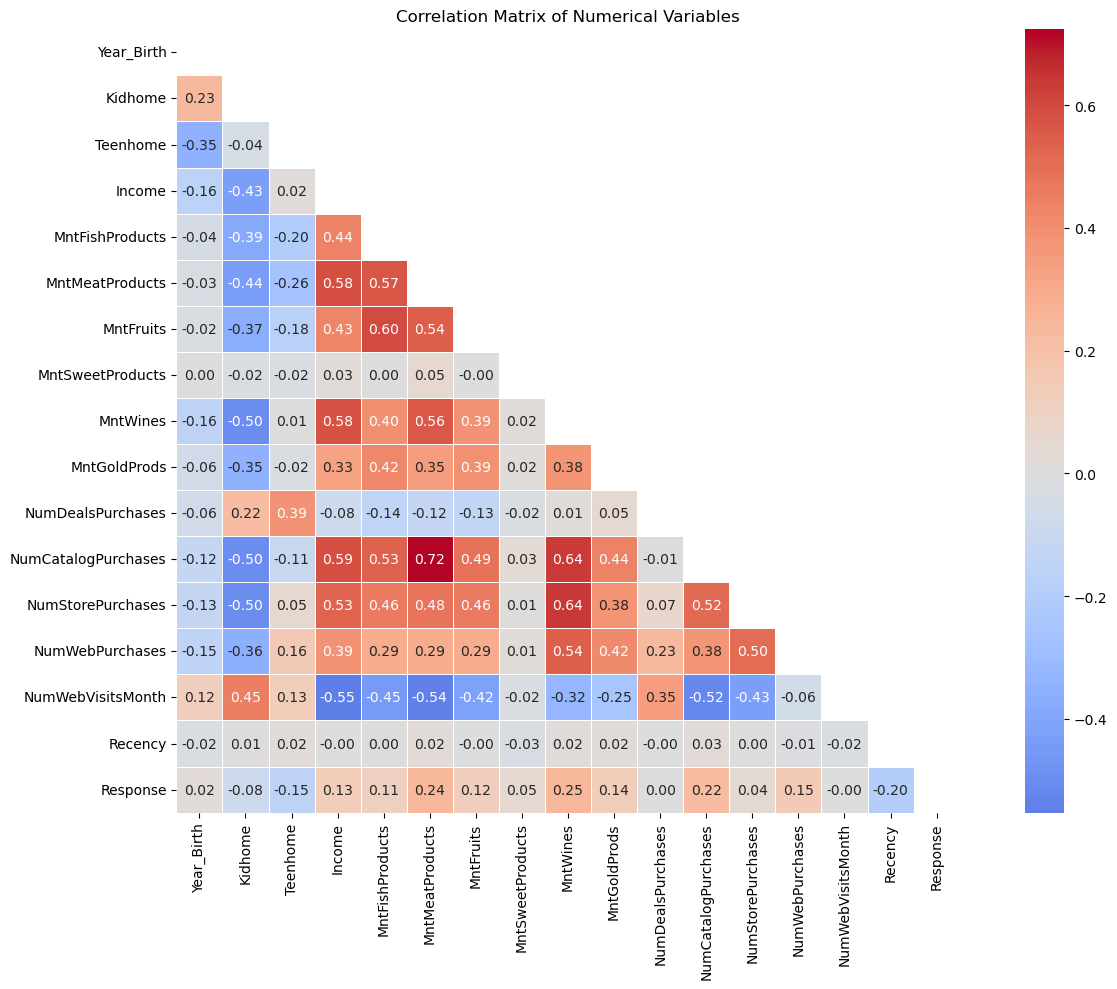

In [13]:
#Correlation matrix of numerical variables
plt.figure(figsize=(14, 10))
corr = ds[numerical_cols + ['Response']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

Observations: 
 + Correlation between variables of income, catalog, meat products, wines, gold products, and store purchases. 
 + Catalog purchases and meat products have the highest correlation, followed by catalog and store purchases of wine products.  
 + The least correlation of these variables is the number of visits by month with the income and meat products. 

##### Date Variable Info

In [14]:
#Convert date, explore enrollment date
ds['Dt_Customer'] = pd.to_datetime(ds['Dt_Customer'])
print("Date range:", ds['Dt_Customer'].min(), "to", ds['Dt_Customer'].max())


Date range: 2012-07-30 00:00:00 to 2042-11-09 00:00:00


## Model Evaluation and Results


Models in: 
+ Model Decision Trees.  *File Name:* ML_02_Model_DecisionTrees.ipynb
+ Model K-Nearest Neighbor (KNN).  *File Name:* ML_Model_KNN.ipynb
+ Model Logistic Regression.  *File Name:* ML_02_Model_LogisticR.ipynb
+ Models: Support Vector Machine (SVM), Neural networks and Naïve Bayes.  *File Name:* ML_02_Model_SVN_NN_NB.ipynb

### Performance Comparison

**Classification Performance at default** 

| Model | Accuracy | Precision | Recall | F1 Score | AUC | Training AUC | GAP | 
|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.8237 | 0.4483 | 0.7761 | 0.5683| 0.9028 | 0.8924 (CV)	| 0.0000|
| Decision Tree | 0.7746 | 0.3672| 0.7015 | 0.4821 | 0.7916 | 0.9122 | 0.0856|
| KNN | 0.8613| 0.8333 | 0.0758| 0.1389 |0.8641 | 0.8880 | 0.0138 |
| Neural Network | 0.8143 | 0.4254 | 0.6786 | 0.5229 | 0.8235 | 0.9580 | 0.1345 |
| SVM |	0.7946 | 0.3806 | 0.6145 | 0.4700 | 0.8310 | 0.9753 | 0.1443| 
| Naive Bayes | 0.7571 | 0.3289 | 0.5952 | 0.4237 | 0.7135 | 0.8260 | 0.1125| 

=== 

**Performance at optimal threshold** 

| Model | Opt. threshold | Accuracy | Precision | Recall | F1 Score | AUC | Lift (decile 1) | Overfitting | 
|---|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.58 | 0.8616 | 0.5281 | 0.7015 | 0.6026 | 0.9028 | 4.56 | None |
| Decision Tree | 0.59 | 0.8080 | 0.4112 | 0.6567 | 0.5057 | 0.7916| 3.04 | Mild (0.086) | 
| KNN | 0.11 | 0.8277 | 0.4505 | 0.7576 | 0.5650 | 0.8641 | 4.46 | None (0.014) | 
| Neural Network | 0.50 | 0.8143 | 0.4254 | 0.6786 | 0.5229 | 0.8235 | — | High (0.135) |
| SVM (randomised) | 0.50 | 0.8018 | 0.4079 | 0.7470  | 0.5277 | 0.8579| — | Mild (0.038) |
| Naive Bayes | 0.50 | 0.7571 | 0.3289 | 0.5952 | 0.4237 | 0.7135 | — | Moderate (0.113) | 

#### Financial Parameters:
* Cost to reach out to a customer: 3 € (Applies to all contacted customers: True Positives and False Positives)
* Revenue from a positive response: 11 € (Applies only to True Positives)
* Net Profit per successful conversion (TP): +8 € (11 € Revenue - 3 € Cost)
* Net Loss per wasted contact (FP): -3 € (Money wasted on non-responders)


#### ROI Calculation

Based on the confusion matrix results from the test data, here is the direct financial impact of each model's predictions:

| Predictive Model | True Positives | False Positives | Total Campaign Cost | Gross Revenue | Net Profit (ROI) |
|:---|:---:|:---:|:---:|:---:|:---:|
| SVM | 62 | 90 | €456 | €682 | €226 |
| Neural Network | 57 | 77 | €402 | €627 | €225 |
| Logistic Regression | 34 | 30 | €192 | €374 | €182 |
| Decision Tree | 44 | 63 | €321 | €484 | €163 |
| KNN | 27 | 29 | €168 | €297 | €129 |
| Naive Bayes | 50 | 102 | €456 | €550 | €94|

## Evaluation 


**Logistic Regression**
Best AUC · Best Lift · Recommended

Logistic Regression achieves the highest AUC of all six models (0.9028) and the strongest lift at decile 1 (4.56×), meaning the top 10% of customers ranked by this model contain 4.56 times more responders than random. It is the only model with no overfitting gap (train AUC ≈ CV AUC ≈ 0.892). The model benefits from class_weight='balanced', which directly compensates for the 85/15 imbalance during training, and from smooth, fully calibrated probabilities that make the ranked contact list reliable. Key drivers identified: Recency (negative — recent buyers respond more), TotalAccepted (positive — past acceptors respond again), and Teenhome/Marital_Status_Married (negative — family commitments reduce response). It ranks 3rd on ROI (€182) because its conservative default threshold contacts fewer customers, but its optimal threshold and budget sensitivity curve show much higher potential. For any deployment that relies on probability scores or ranked lists, this is the correct choice.

__________

**KNN** 
Best No-Overfit · Strong AUC · Ranking tool

KNN achieves AUC 0.8641 and shows no overfitting (Train–CV gap = 0.014), making it the most generalisable model after Logistic Regression. Its lift at decile 1 (4.46×) is nearly as strong as Logistic Regression's. However, KNN has a structural limitation in this dataset: it has no class_weight parameter, so at the default threshold of 0.5 it achieves Recall of only 0.076 — meaning it identifies almost no responders. The optimal threshold must be dropped to 0.11 because KNN probabilities are coarse (only 37 distinct values, in steps of 1/73 ≈ 0.014). This coarseness also reduces ROI reliability (ranked 5th, €129), since the probability scores cannot finely distinguish customers within the same neighbourhood bucket. KNN is best used as a ranking engine when AUC is the only priority, not as a standalone classifier where probability calibration matters.

__________

**SVM (randomised search)**
Best ROI · Highest Recall · Production viable

The randomised SVM (kernel=linear, C=0.022) achieves the highest ROI of all six models (€226) and the highest Recall (0.747), meaning it correctly identifies the most responders. The linear kernel combined with SMOTE training brings the Train–CV gap down to a manageable 0.038, far better than the default SVC (gap 0.144). Its AUC of 0.858 is the second-highest. The ROI advantage comes directly from Recall: because catching a responder earns +€8 while a wasted contact only costs −€3, high Recall is worth more than high Precision in this cost structure. The trade-off is that SVM requires Platt scaling for probability output (less reliable than LR), and its linear boundary means it cannot natively capture feature interactions. For campaigns where maximising contacts with likely responders is the priority and the budget covers higher FP rates, SVM is the financially strongest choice.

__________

**Neural Network**
Good metrics · High train gap · Over-engineered

The Neural Network achieves the second-highest ROI (€225) and reasonable Recall (0.679). However, its Train AUC of 0.958 versus Test AUC of 0.824 reveals an overfitting gap of 0.135 — the largest of all models. This is expected: with only ~2,200 rows and 15% positive cases, neural networks are over-parameterised for this scale of data. SMOTE was applied to balance training to 1:1, which helps Recall but introduces synthetic samples that may not represent real customer behaviour. The architecture found by GridSearch — only 7 neurons across 2 layers — is telling the data does not support more complexity. AUC of 0.8235 is weaker than LR, KNN, and SVM. Neural networks become genuinely advantageous at 10,000+ rows with richer feature sets. For this dataset, simpler models outperform it on both AUC and reliability.

__________

**Decision Tree**
Best interpretability · Mild overfit · Communication tool

The Decision Tree achieves AUC 0.7916 (satisfactory) and Recall 0.657 at its optimal threshold, making it the weakest performer on discrimination metrics among practically useful models. The GridSearch found max_depth=6 with min_samples_leaf=30 as the best regularisation, but even this produces a Train-CV gap of 0.086 — mild overfitting. Its ROI of €163 is 4th. However, the Decision Tree's unique advantage is its human-readable rule structure: the first split on TotalAccepted ≤ 0.5 immediately gives marketers an actionable segment, and the path Recency ≤ 20.5 -> Response=1 can be implemented as a business rule without any model infrastructure. Feature importance confirms: TotalAccepted (35%), Recency (20%), Seniority (17%), TotalSpent (6%). Use it alongside Logistic Regression — LR generates the ranked list, Decision Tree explains the strategy to management.

__________

**Naive Bayes** 
Lowest AUC · Worst Precision · Do not deploy

Naive Bayes achieves the lowest AUC (0.7135), the lowest Precision (0.329), the lowest F1 (0.424), and the lowest ROI (€94) despite SMOTE balancing. Its core assumption — that all features are conditionally independent given the class — is fundamentally violated by this dataset. Income, TotalSpent, MntWines, and MntMeatProducts are strongly correlated; treating them as independent causes the model to double-count their evidence and produce miscalibrated probabilities. The model also requires all inputs to be categorical or binned for the Gaussian version to perform correctly, which conflicts with the continuous nature of most features. Despite being the fastest to train (~0.007s), speed is irrelevant when the model's assumptions are broken. Naive Bayes is retained as a teaching baseline only — its results serve as a lower bound against which other models should be compared.


## To Deplyment

**Logistic Regression** remains the recommended deployment model because it has the highest AUC (the only threshold-independent metric), the strongest lift at decile 1, zero overfitting, and calibrated probabilities. For campaigns with a pure revenue-maximisation objective and the budget to absorb more wasted contacts, the tuned SVM becomes the financially optimal choice.

The second choise is **SVM** in a ROI pespective. 
The cost structure used in the SVM (€3 contact cost, €11 revenue) strongly rewards Recall over Precision. With net profit per TP = +€8 and net loss per FP = −€3, you need 2.67 false positives to cancel one true positive. SVM's high Recall (0.747) captures enough extra responders to outweigh its larger false-positive count. Logistic Regression's more conservative targeting (34 TP vs 62 TP) produces lower gross revenue despite better precision. If contact costs were higher relative to revenue, LR would win.